# Analysis of Wine

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd

In [12]:
# Read dataset

vivino_dataset = pd.read_csv('../data/vivino_wines_2026/vivino_wines_2026.csv')
wine_enthusiast_dataset = pd.read_csv('../data/WineEnthusiast-data/winemag-data-130k-v2.csv')

In [13]:
vivino_dataset.head()

,wine_id,vintage_id,full_name,wine_name,winery_name,vintage_year,rating,ratings_count,wine_type,region,country,is_natural,vivino_url,scraped_at
0,6844921,NaN,TerraNoble Reserva Especial Carménère,Reserva Especial Carménère,TerraNoble,NaN,3.9,341,Red,Aconcagua Valley,Chile,False,https://www.vivino.com/reserva-especial-carmen...,2026-02-26T12:14:34.782Z
1,2801506,NaN,Lindeman's Regional Series Chardonnay,Regional Series Chardonnay,Lindeman's,NaN,3.3,666,White,Adelaide Hills,Australia,False,https://www.vivino.com/regional-series-chardon...,2026-02-26T12:14:32.449Z
2,1744558,NaN,Alta Vista Alto Agrelo Grande Reserve Malbec,Alto Agrelo Grande Reserve Malbec,Alta Vista,NaN,3.6,154,Red,Agrelo,Argentina,False,https://www.vivino.com/alto-agrelo-grande-rese...,2026-02-26T12:14:36.464Z
3,2435902,NaN,Bodega Norton Lote Agrelo Malbec,Lote Agrelo Malbec,Bodega Norton,NaN,4.0,2088,Red,Agrelo,Argentina,False,https://www.vivino.com/lote-agrelo-malbec/w/24...,2026-02-26T12:14:33.221Z
4,5074467,NaN,Catena Appellation Agrelo Cabernet Sauvignon,Appellation Agrelo Cabernet Sauvignon,Catena,NaN,3.9,3850,Red,Agrelo,Argentina,False,https://www.vivino.com/appellation-agrelo-cabe...,2026-02-26T12:14:26.630Z


In [14]:
wine_enthusiast_dataset.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


In [15]:
wine_enthusiast_dataset.iloc[0]["description"]

"Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity."

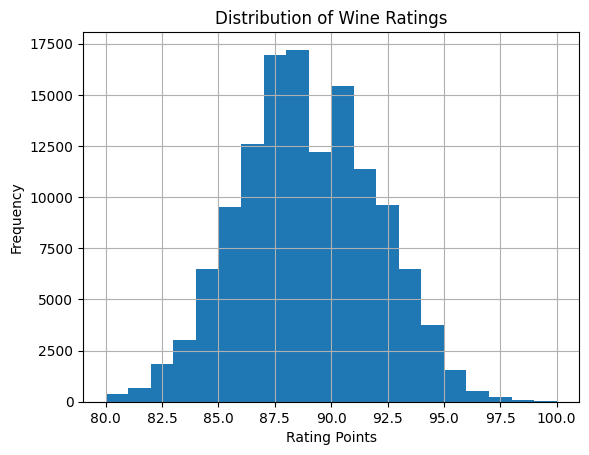

In [ ]:
wine_enthusiast_dataset["points"].hist(bins=20)
mean_points = wine_enthusiast_dataset["points"].mean()
plt.axvline(mean_points, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_points:.2f}")
plt.legend()
plt.title("Distribution of Wine Ratings")
plt.xlabel("Rating Points")
plt.ylabel("Frequency")
plt.show()

## Using review sentiment to predict rating

Using Wine Enthusiast Dataset, we will try both regression and classification.

### Regression